In [2]:
import numpy as np
import pandas as pd
from scipy import stats

# 1. Select metric type here ("std" or "ci")
STAT_TYPE = "std"  # Change to "ci" whenever you want Confidence Intervals


def summarize_metric(group, column, stat_type=STAT_TYPE, confidence=0.95):
    """Summarizes a column as Mean ± [Std | CI] (raw_values)."""
    values = group[column].dropna().to_numpy(dtype=float)
    n = len(values)

    if n == 0:
        return "N/A"

    mean = np.mean(values)

    if n > 1:
        if stat_type == "std":
            margin = np.std(values, ddof=1)
        elif stat_type == "ci":
            sem = stats.sem(values)
            margin = sem * stats.t.ppf((1 + confidence) / 2, df=n - 1)
        else:
            raise ValueError("stat_type must be either 'std' or 'ci'")

        margin_str = f"{margin:.2f}"
    else:
        margin_str = "N/A"

    actual = ", ".join(f"{x:.2f}" for x in values)

    return f"{mean:.2f} ± {margin_str} ({actual})"




from pathlib import Path
import json

import numpy as np
import pandas as pd


def summarize_run(run_dir, tail_n=5):
    run_dir = Path(run_dir)

    with open(run_dir / "args.json", encoding="utf-8") as f:
        args = json.load(f)

    fid_path = run_dir / "validation_fid.jsonl"
    fids = []

    if fid_path.exists():
        with open(fid_path, encoding="utf-8") as f:
            fids = [
                json.loads(line)
                for line in f
                if line.strip()
            ]

    row = {
        "run": str(run_dir),
        **{f"arg_{key}": value for key, value in args.items()},
        "fid_best": np.nan,
        "fid_best_iteration": np.nan,
        "fid_final": np.nan,
        "fid_final_iteration": np.nan,
        "fid_tail_median": np.nan,
        "fid_tail_mean": np.nan,
        "fid_tail_max": np.nan,
        "fid_tail_n": 0,
    }

    if fids:
        values = np.array([item["fid"] for item in fids], dtype=float)
        iterations = np.array([item["iteration"] for item in fids])

        tail = values[-tail_n:]

        best_index = np.argmin(values)

        row.update({
            "fid_best": values[best_index],
            "fid_best_iteration": iterations[best_index],
            "fid_final": values[-1],
            "fid_final_iteration": iterations[-1],
            "fid_tail_median": np.median(tail),
            "fid_tail_mean": np.mean(tail),
            "fid_tail_max": np.max(tail),
            "fid_tail_n": len(tail),
        })

    return row

def summarize_runs(experiment_dirs, tail_n=5):
    """Summarizes all run subdirectories found inside multiple experiment directories."""
    rows = []

    # Handle both a single path string/Path object and a list of paths
    if isinstance(experiment_dirs, (str, Path)):
        experiment_dirs = [experiment_dirs]

    for exp_dir in experiment_dirs:
        exp_path = Path(exp_dir)

        # Iterate through subdirectories inside each experiment root
        for run_dir in exp_path.iterdir():
            # Check if it's a directory and contains args.json
            if run_dir.is_dir() and (run_dir / "args.json").exists():
                rows.append(summarize_run(run_dir, tail_n=tail_n))

    return pd.DataFrame(rows)

# Example usage:


In [3]:
# 2. Build comparison DataFrame
suffix = "std" if STAT_TYPE == "std" else "95ci"

dirs = [
    "/home/satoshi/projects/fcmstylegan/experiments/eeeg/dcgan/explore_ema_diffaug/",
    "/home/satoshi/projects/fcmstylegan/experiments/eeeg/dcgan/explore_profencoder/",
]
df = summarize_runs(dirs)


comparison = (
    df.groupby(
        [
            # "arg_seed",
            "fid_final_iteration",
            "arg_base_channels",
            "arg_profile_encoder",
            "arg_diff_aug_policy",
            "arg_ema",
        ],
        dropna=False,
    )
    .apply(
        lambda g: pd.Series({
            "runs": len(g),
            f"tail_fid_{suffix}": summarize_metric(g, "fid_tail_median", stat_type=STAT_TYPE),
            f"best_fid_{suffix}": summarize_metric(g, "fid_best", stat_type=STAT_TYPE),
            f"final_fid_{suffix}": summarize_metric(g, "fid_final", stat_type=STAT_TYPE),
            f"tail_max_fid_{suffix}": summarize_metric(g, "fid_tail_max", stat_type=STAT_TYPE),
        })
    )
)

display(comparison)

runs  \
fid_final_iteration arg_base_channels arg_profile_encoder arg_diff_aug_policy arg_ema         
200000              512               cnn                                     False       7   
                                      mlp                                     False       5   
                                                                              True        2   
                                                          color               False       2   
                                                                              True        2   
                                                          cutout              False       2   
                                                                              True        2   
                                                          translation         False       2   
                                                                              True        2   

                                                                                                                            tail_fid_std  \
fid_final_iteration arg_base_channels arg_profile_encoder arg_diff_aug_policy arg_ema                                                      
200000              512               cnn                                     False    64.51 ± 16.34 (58.82, 57.03, 101.46, 57.77, 57...   
                                      mlp                                     False     37.27 ± 6.19 (44.64, 38.44, 33.20, 29.08, 41.01)   
                                                                              True                           40.23 ± 2.30 (38.60, 41.86)   
                                                          color               False                         47.89 ± 16.27 (59.40, 36.38)   
                                                                              True                           41.83 ± 3.74 (44.47, 39.18)   
                                                          cutout              False                       122.12 ± 86.70 (183.43, 60.81)   
                                                                              True                       152.60 ± 154.18 (43.58, 261.62)   
                                                          translation         False                         76.51 ± 26.39 (95.16, 57.85)   
                                                                              True                         100.32 ± 8.46 (94.33, 106.30)   

                                                                                                                            best_fid_std  \
fid_final_iteration arg_base_channels arg_profile_encoder arg_diff_aug_policy arg_ema                                                      
200000              512               cnn                                     False    39.09 ± 5.28 (39.50, 45.95, 34.52, 34.32, 34.3...   
                                      mlp                                     False     26.67 ± 2.09 (28.46, 25.91, 25.74, 24.07, 29.15)   
                                                                              True                           32.58 ± 1.25 (33.47, 31.70)   
                                                          color               False                          32.66 ± 5.63 (36.64, 28.68)   
                                                                              True                           34.68 ± 1.14 (33.87, 35.48)   
                                                          cutout              False                          31.41 ± 1.32 (32.34, 30.48)   
                                                                              True                           37.27 ± 2.98 (35.17, 39.38)   
                                                          translation         False                          32.19 ± 6.44 (36.74, 27.64)   
                                                                              True                  

### Takeaways
- EMA does make it slightly worse. 
- diff_aug does not really help, at least for this settings. making lr lower or differnet base channels may make a difference. 
- somehow cnn profile encoder seems to do worse...

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)
df.query("arg_profile_encoder=='mlp' and arg_diff_aug_policy=='' and not arg_ema")

,run,arg_datasplit,arg_preprocessed_root,arg_brightfield_postfix,arg_split_column,arg_latent,arg_profile_encoder,arg_base_channels,arg_size,arg_iter,arg_batch,arg_n_sample,arg_sample_every,arg_checkpoint_every,arg_fid_every,arg_fid_batch,arg_fid_samples,arg_diff_aug_policy,arg_ema,arg_ema_decay,arg_lr,arg_beta1,arg_num_workers,arg_bf16,arg_compile_mode,arg_ckpt,arg_exp_dir,arg_seed,fid_best,fid_best_iteration,fid_final,fid_final_iteration,fid_tail_median,fid_tail_mean,fid_tail_max,fid_tail_n
1,/home/satoshi/projects/fcmstylegan/experiments/eeeg/dcgan/explore_ema_diffaug/20260817_231036,./data/task1_dataset_split.csv,/dev/shm/satoshi.tsutsui/data/task1_processed/,_brightfield_crop_masked_normalized_avebg_pad128.png,split,128,mlp,512,128,200000,128,64,1000,10000,5000,None,None,,False,0.999,0.0002,0.5,4,True,default,None,experiments/dcgan/explore_ema_diffaug,0,28.457971,165000,37.156898,200000,44.636149,46.839508,64.912650,5
3,/home/satoshi/projects/fcmstylegan/experiments/eeeg/dcgan/explore_ema_diffaug/20260818_024117,./data/task1_dataset_split.csv,/dev/shm/satoshi.tsutsui/data/task1_processed/,_brightfield_crop_masked_normalized_avebg_pad128.png,split,128,mlp,512,128,200000,128,64,1000,10000,5000,None,None,,False,0.999,0.0002,0.5,4,True,default,None,experiments/dcgan/explore_ema_diffaug,1,25.907855,175000,30.584398,200000,38.443481,39.225659,49.094722,5
23,/home/satoshi/projects/fcmstylegan/experiments/eeeg/dcgan/explore_profencoder/20260819_084001,./data/task1_dataset_split.csv,/dev/shm/satoshi.tsutsui/data/task1_processed/,_brightfield_crop_masked_normalized_avebg_pad128.png,split,128,mlp,512,128,200000,128,64,1000,10000,5000,None,None,,False,0.999,0.0002,0.5,4,True,default,None,experiments/dcgan/explore_profencoder,2,25.738490,175000,32.375958,200000,33.201451,34.065479,39.018065,5
24,/home/satoshi/projects/fcmstylegan/experiments/eeeg/dcgan/explore_profencoder/20260819_084323,./data/task1_dataset_split.csv,/dev/shm/satoshi.tsutsui/data/task1_processed/,_brightfield_crop_masked_normalized_avebg_pad128.png,split,128,mlp,512,128,200000,128,64,1000,10000,5000,None,None,,False,0.999,0.0002,0.5,4,True,default,None,experiments/dcgan/explore_profencoder,4,24.074614,140000,33.976583,200000,29.081638,30.735430,33.976583,5
25,/home/satoshi/projects/fcmstylegan/experiments/eeeg/dcgan/explore_profencoder/20260819_084428,./data/task1_dataset_split.csv,/dev/shm/satoshi.tsutsui/data/task1_processed/,_brightfield_crop_masked_normalized_avebg_pad128.png,split,128,mlp,512,128,200000,128,64,1000,10000,5000,None,None,,False,0.999,0.0002,0.5,4,True,default,None,experiments/dcgan/explore_profencoder,5,29.154437,105000,49.642586,200000,41.006877,42.072465,49.642586,5


In [20]:
# fid_path = "/home/satoshi/projects/fcmstylegan/experiments/eeeg/dcgan/explore_ema_diffaug/20260817_231036/validation_fid.jsonl"
fid_path = "../experiments/archive/dcgan_baseline_20260817_231036/validation_fid.jsonl"
with open(fid_path, encoding="utf-8") as f:
    fids = [
        json.loads(line)
        for line in f
        if line.strip()
    ]
df_fid_all = pd.DataFrame(fids)
df_fid = df_fid_all.query("iteration%10000==0")#because checkpoing is every 10000 
# df_fid.plot(x="iteration",y="fid")
display(df_fid)

,iteration,fid
1,10000,74.810016
3,20000,68.594581
5,30000,46.915553
7,40000,49.770149
9,50000,44.097099
11,60000,44.700501
13,70000,58.299980
15,80000,43.978744
17,90000,43.803898
19,100000,44.024038


In [22]:
checkpoint_path = "~/projects/fcmstylegan/experiments/archive/dcgan_baseline_20260817_231036/checkpoint/170000.pt"

  python evaluate.py \
    --model dcgan \
    --ckpt experiments/archive/dcgan_baseline_20260817_231036/checkpoint/170000.pt \
    --datasplit data/task1_dataset_split.csv \
    --preprocessed_root data/task1_processed \
    --split test \
    --use_mask \
    --seed 123 \
    --save_images_dir experiments/archive/dcgan_baseline_20260817_231036/test_eval_imgs \
    --output experiments/archive/dcgan_baseline_20260817_231036/test_eval_stat.json \
    --per_image_output experiments/archive/dcgan_baseline_20260817_231036/test_eval_imgs.jsonl


    python evaluate_saved_crops.py \
    --save_images_dir experiments/archive/dcgan_baseline_20260817_231036/test_eval_imgs \
    --datasplit data/task1_dataset_split.csv \
    --preprocessed_root data/task1_processed \
    --split test \
    --crop_size 70 \
    --output experiments/archive/dcgan_baseline_20260817_231036/test_eval_crop70_stat.json

,value
model,dcgan
checkpoint,/home/satoshi/projects/fcmstylegan/experiments...
split,test
num_samples,34753
seed,123
mask_metrics,True
fid,35.082462
psnr_mean,19.676889
ssim_mean,0.877996
psnr_masked_mean,12.514042


,mean,median,std,min,max,count
psnr,19.6769,20.1830,4.0847,8.1627,28.1595,34753.0000
ssim,0.8780,0.8874,0.0345,0.6040,0.9514,34753.0000
psnr_masked,12.5140,12.7485,1.4748,7.3111,18.0188,34753.0000
ssim_masked,0.0620,0.0604,0.0948,-0.3907,0.5164,34753.0000
lpips,0.1611,0.1533,0.0537,0.0470,0.4816,34753.0000
lpips_crop,0.2682,0.2653,0.0634,0.0993,0.7408,34753.0000


,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part2_T Lymph_32327,28.16,0.9234,15.16,0.1052,0.0926,0.2092


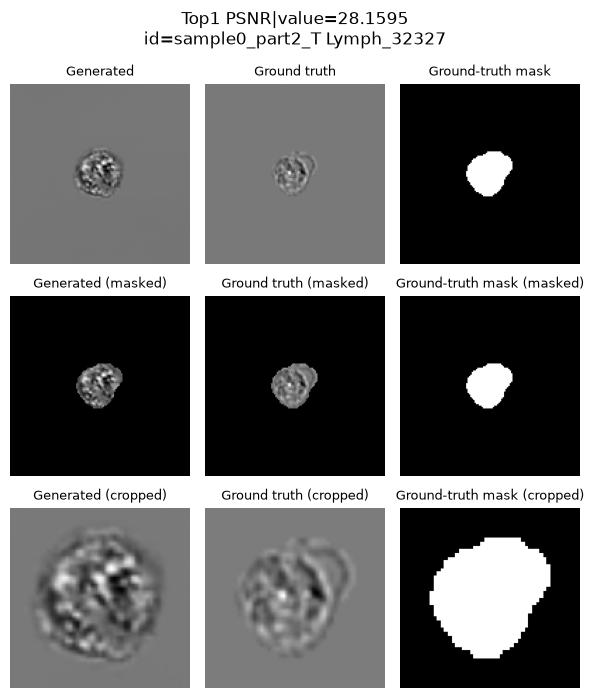

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part1_Neut_14573,20.18,0.8523,13.47,0.0870,0.2302,0.4126


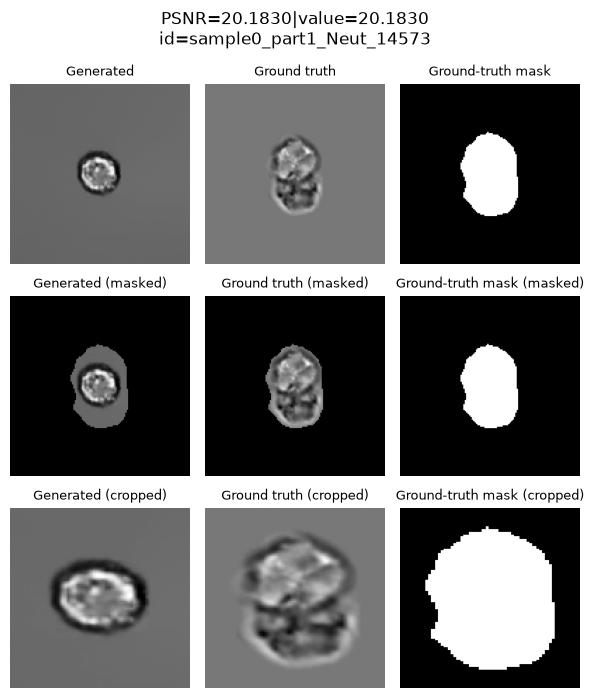

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part1_T Lymph_40714,8.16,0.7517,7.63,0.0274,0.4490,0.5517


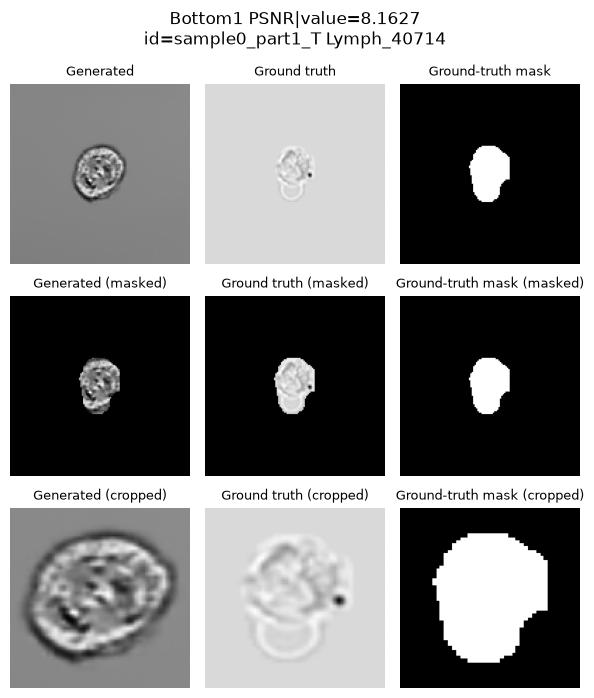

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part2_Eo_8973,24.32,0.9514,15.11,0.4819,0.0925,0.1328


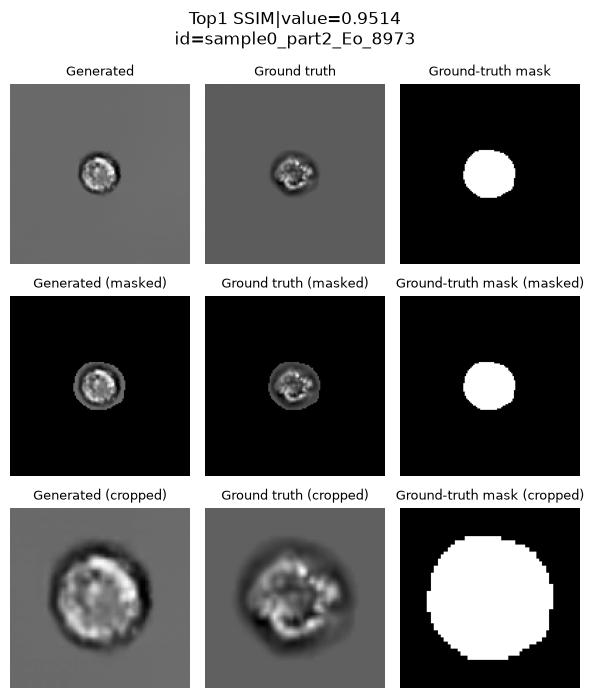

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part3_Neut_31012,23.87,0.8874,13.17,-0.0460,0.1095,0.2589


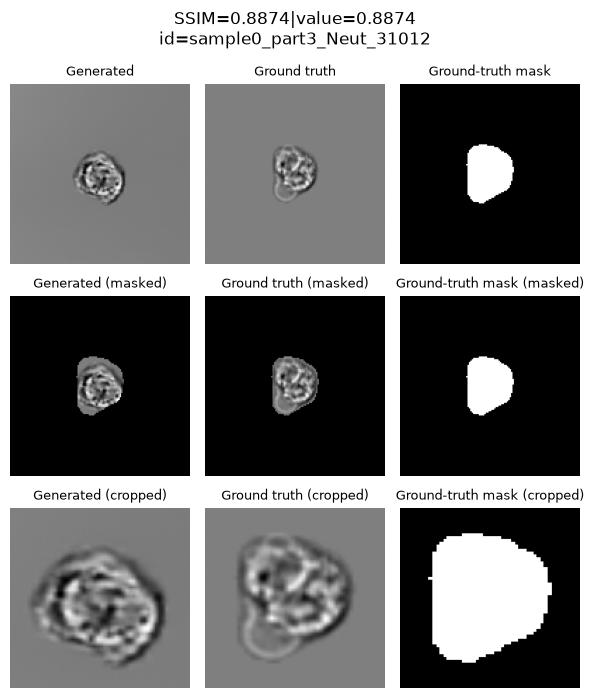

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part3_Neut_21050,8.83,0.6040,9.00,0.0812,0.3361,0.3902


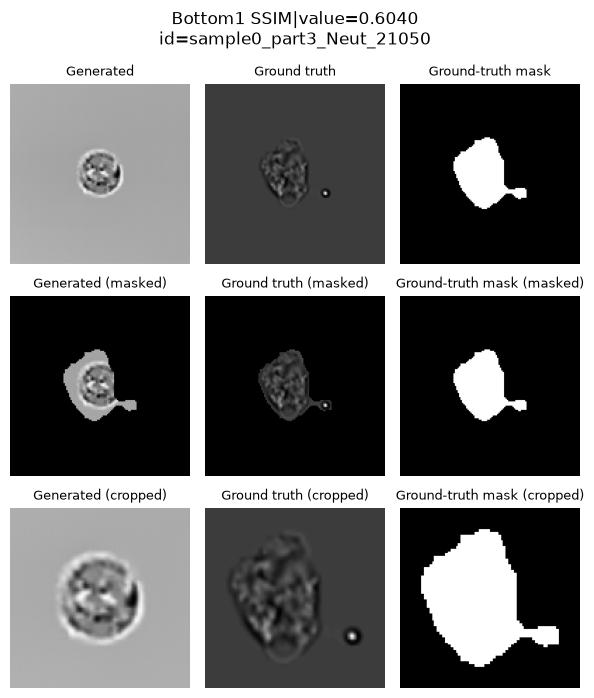

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part3_T Lymph_16508,25.88,0.8698,18.02,0.1070,0.1900,0.3506


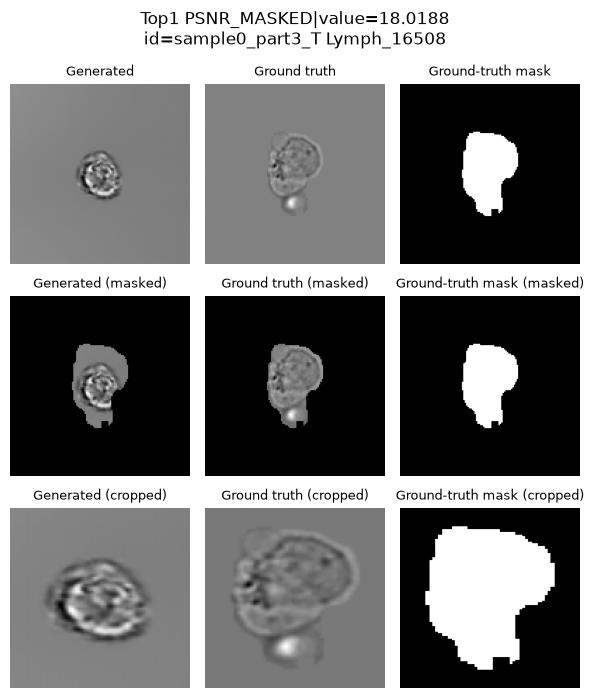

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part2_T Lymph_15814,25.86,0.9235,12.75,0.0827,0.1540,0.3005


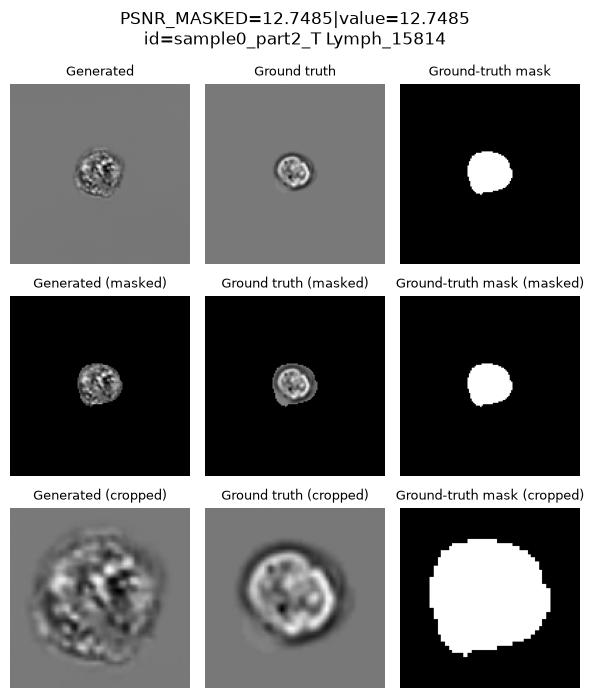

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part2_T Lymph_38681,8.63,0.7844,7.31,0.0279,0.3999,0.5173


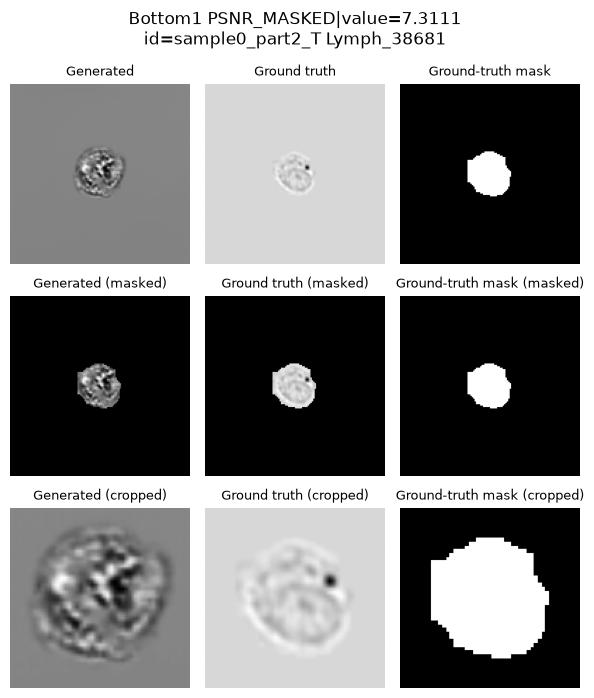

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part2_Neut_33901,21.28,0.9338,16.29,0.5164,0.0769,0.1216


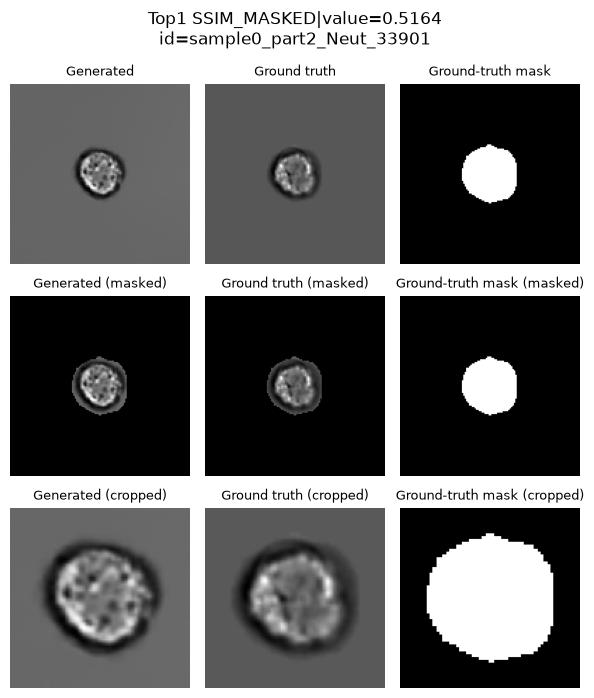

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part1_Neut_10988,21.79,0.8853,13.08,0.0604,0.1844,0.2718


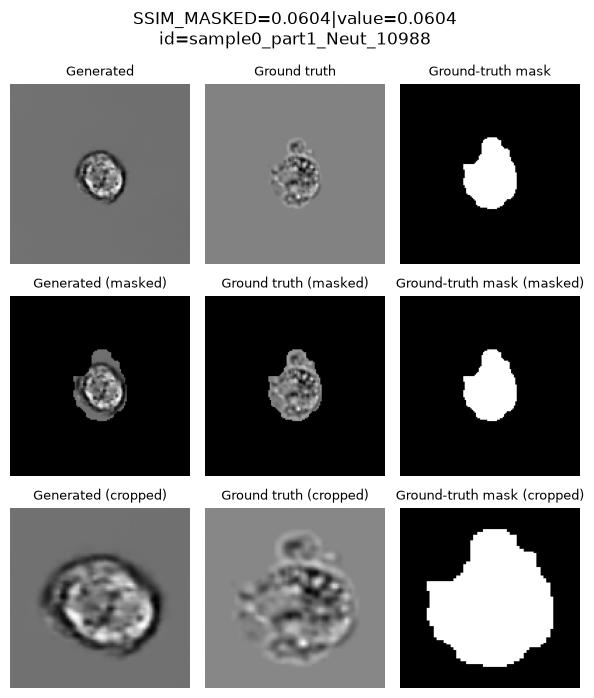

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part2_Neut_11737,18.36,0.8327,9.90,-0.3907,0.1386,0.2250


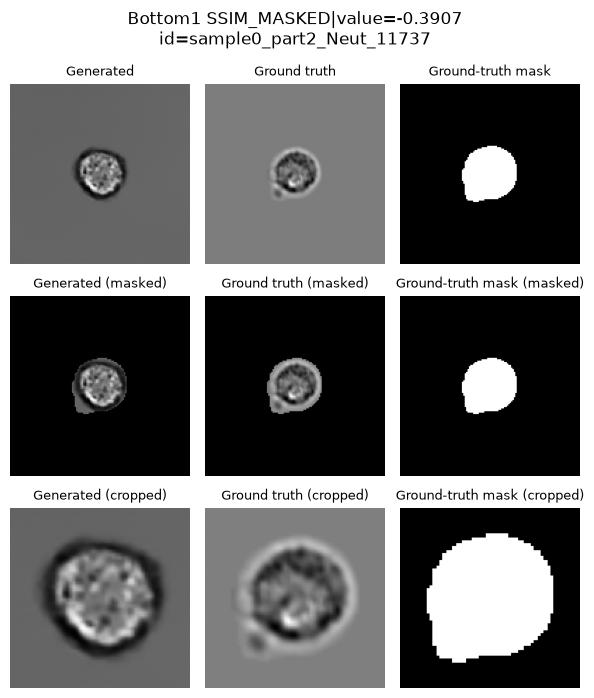

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part1_Neut_15668,25.58,0.9395,15.39,0.4177,0.0470,0.1077


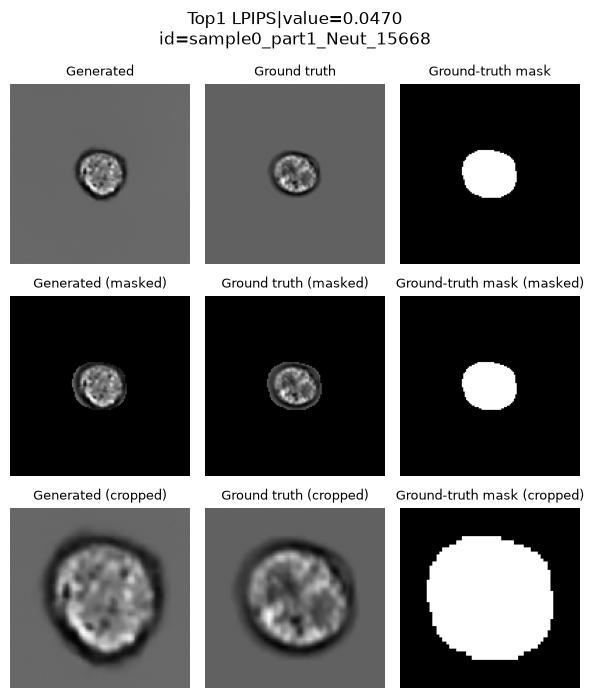

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part1_Neut_35616,21.61,0.8883,11.96,-0.0200,0.1533,0.3071


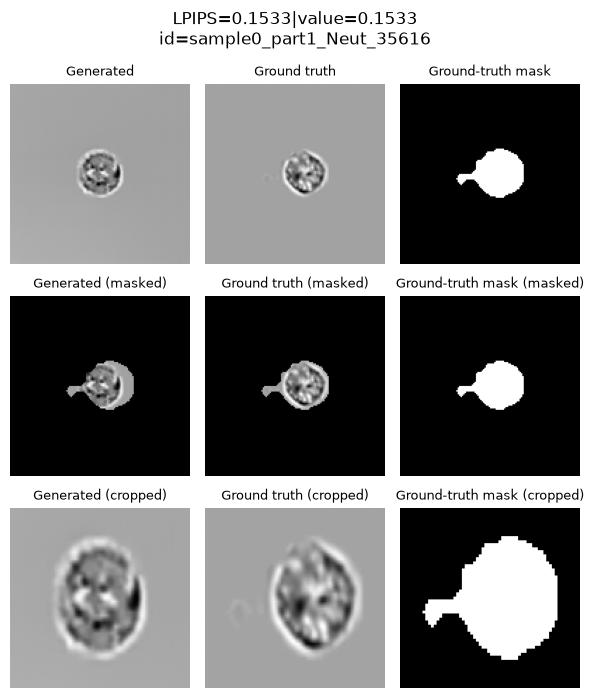

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part3_Neut_42991,8.23,0.7088,7.69,0.0111,0.4816,0.5174


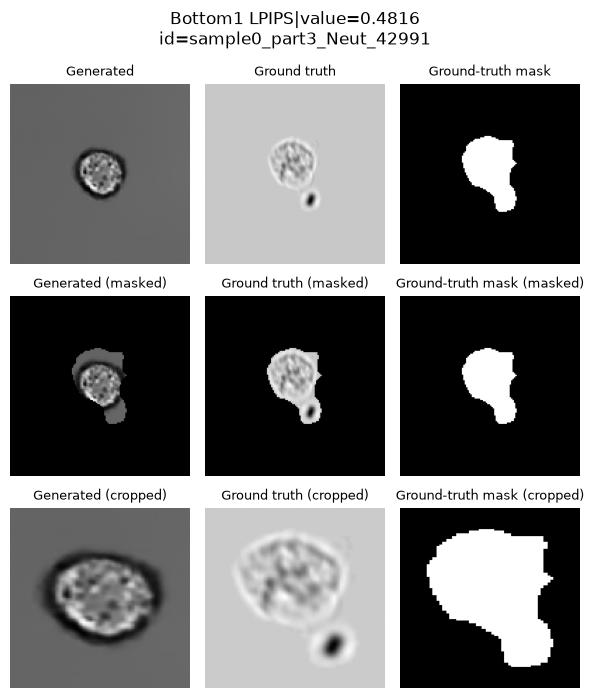

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part1_Neut_47865,24.35,0.9389,14.70,0.3869,0.0488,0.0993


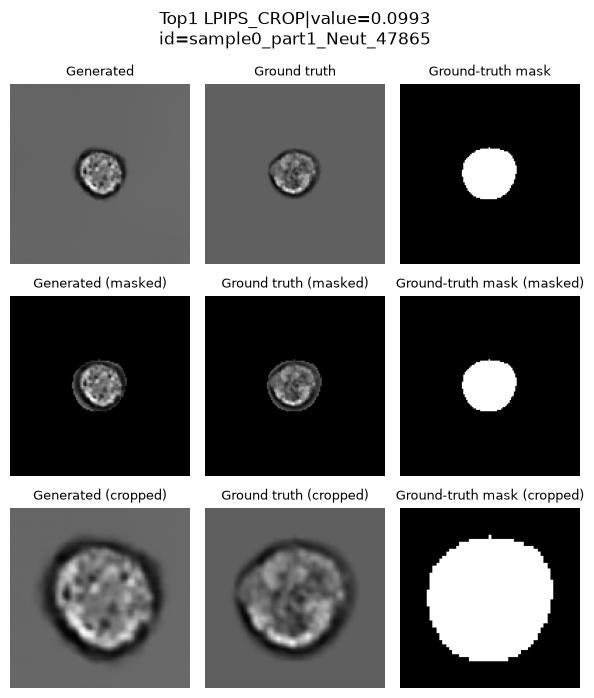

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part2_Neut_44137,15.70,0.8467,12.54,-0.0162,0.1968,0.2653


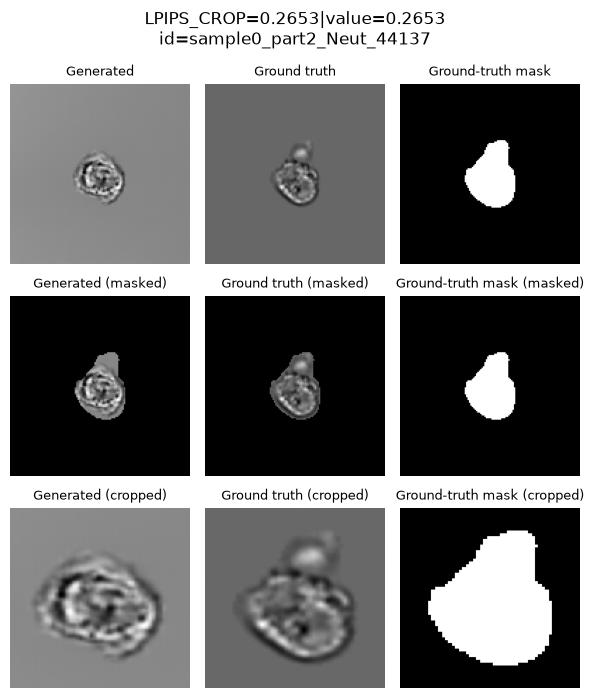

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part2_T Lymph_40268,11.71,0.8522,7.53,-0.1508,0.3583,0.7408


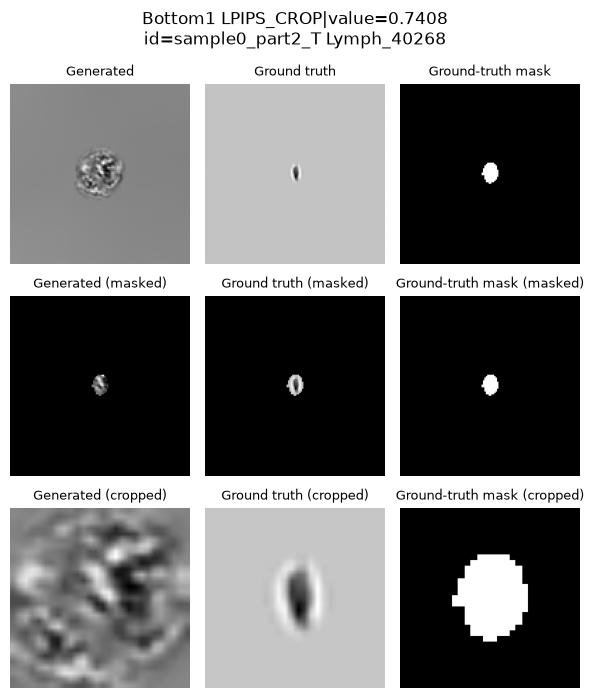

In [1]:
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("jpg")

from pathlib import Path
ROOT = Path("~/projects/fcmstylegan/experiments/archive/dcgan_baseline_20260817_231036").expanduser()
%run -i plot_test_results.py

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part1_B Lymph_14408,21.35,0.9006,11.85,-0.0636,0.1264,0.2567


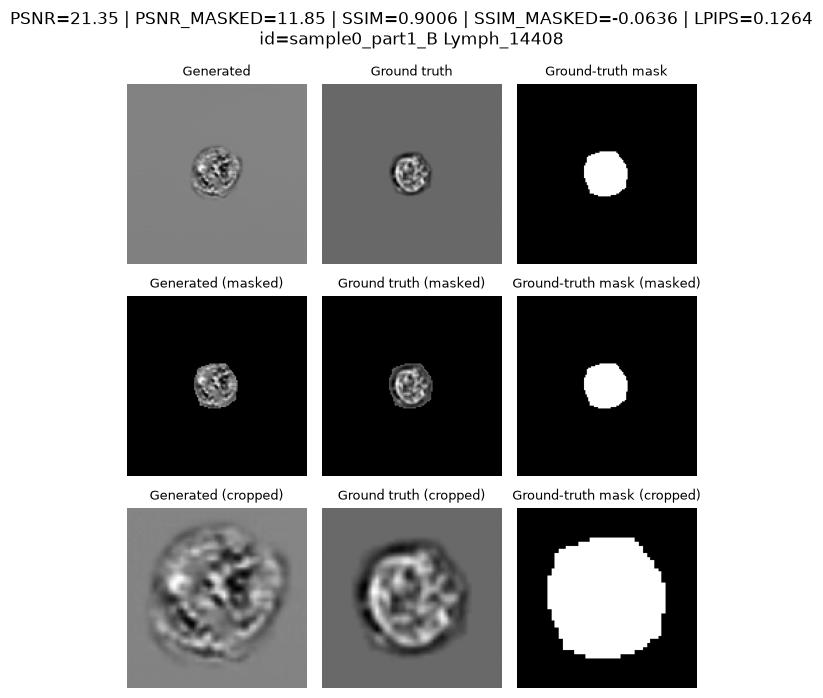

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part3_Eo_5626,26.06,0.9156,14.46,0.0535,0.1101,0.2371


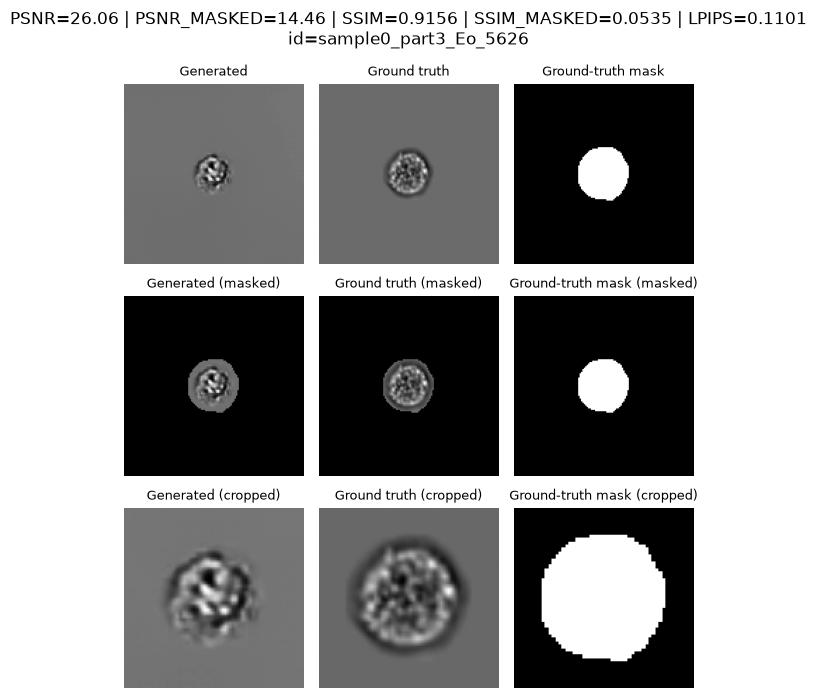

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part3_Mono_45148,22.68,0.8877,13.22,-0.0699,0.1015,0.2109


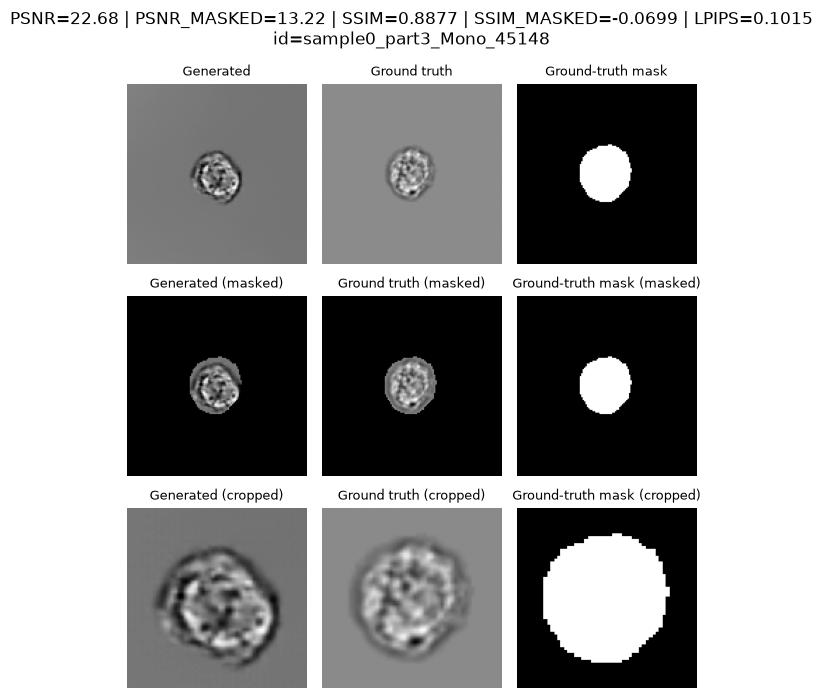

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part1_Neut_39212,21.02,0.8788,12.91,-0.0392,0.1784,0.2840


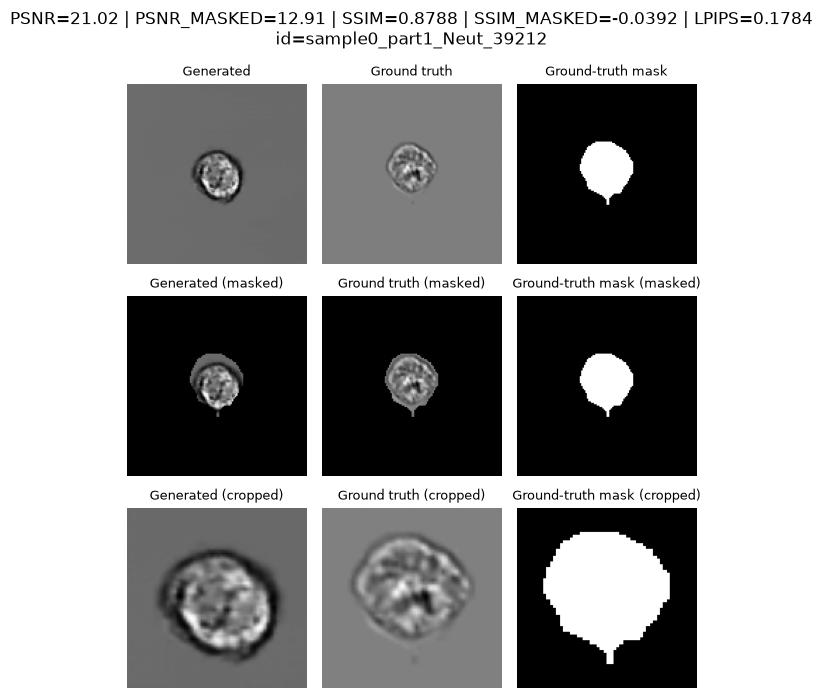

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part1_T Lymph_34817,13.39,0.8237,10.76,0.0416,0.1903,0.2427


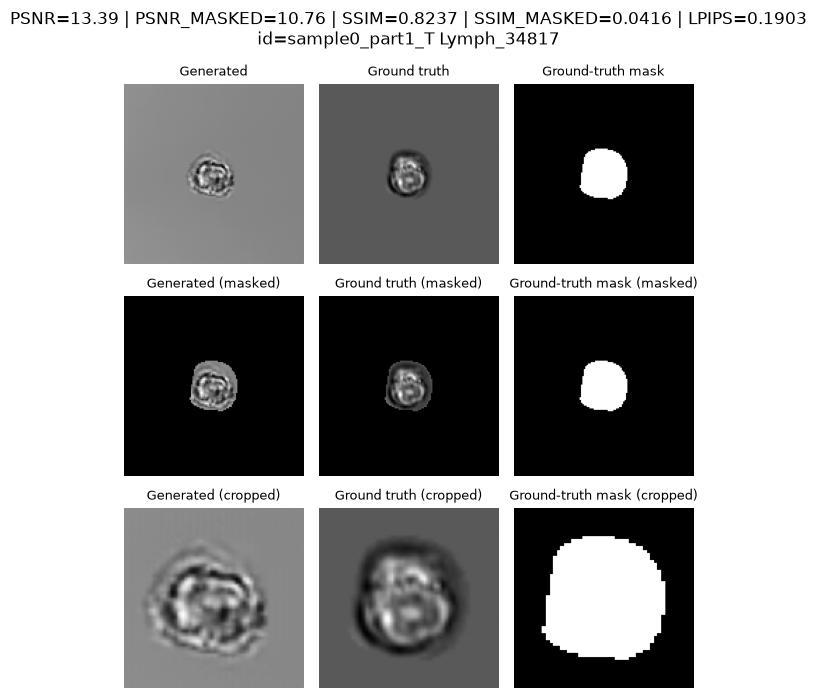

In [2]:
cell_ids = ['sample0_part1_B Lymph_14408',
 'sample0_part3_Eo_5626',
 'sample0_part3_Mono_45148',
 'sample0_part1_Neut_39212',
 'sample0_part1_T Lymph_34817']

for cell_id in cell_ids:

    fig, axes = plot_cell(
        cell_id,
        title_metrics= ["psnr", "psnr_masked", "ssim", "ssim_masked", "lpips"]
    )

    axes[0, 0].set_title("My generated image")
    plt.show()

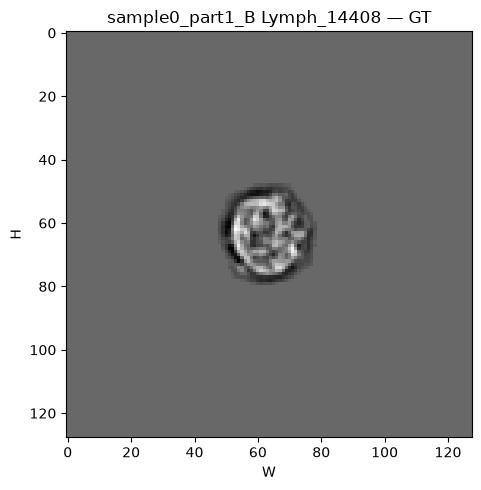

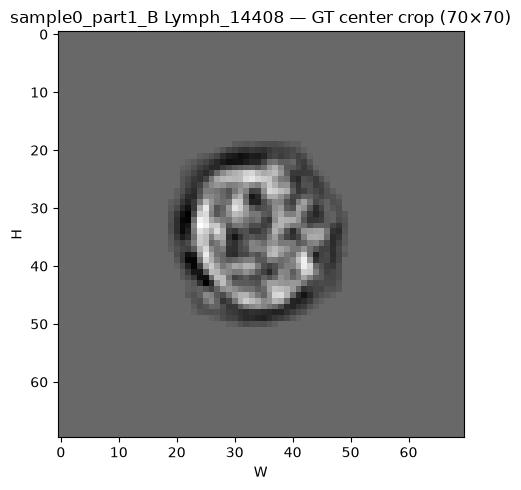

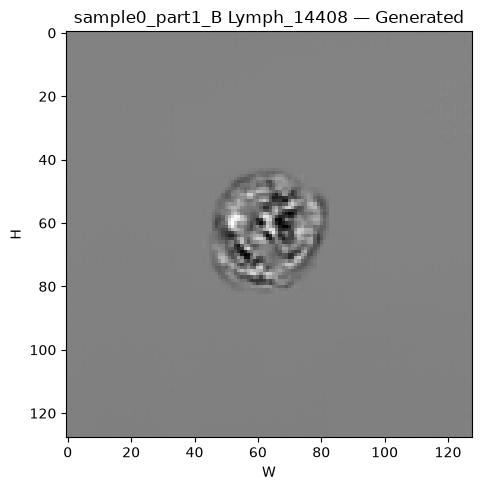

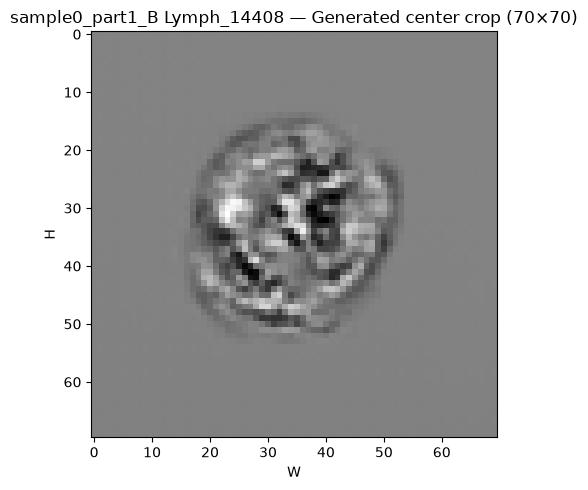

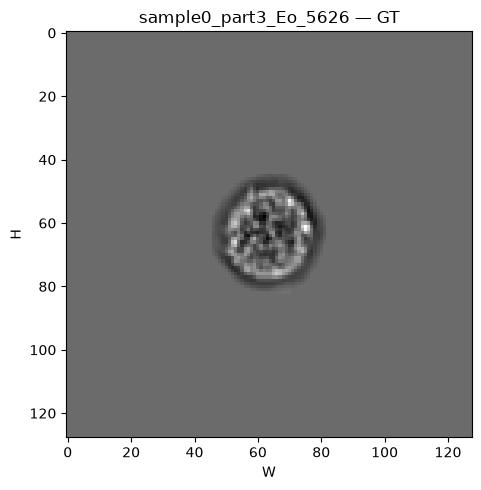

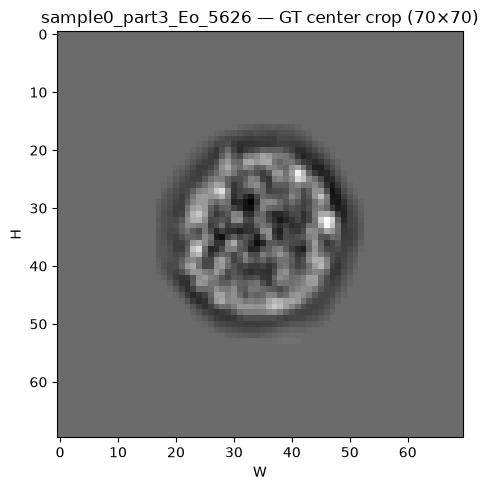

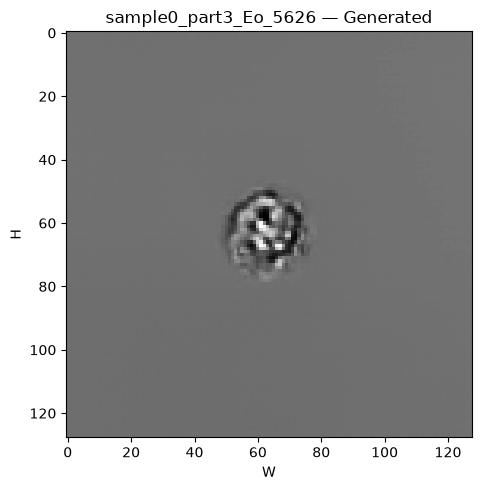

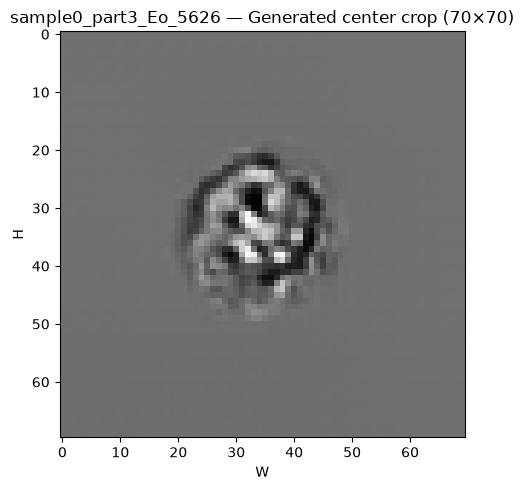

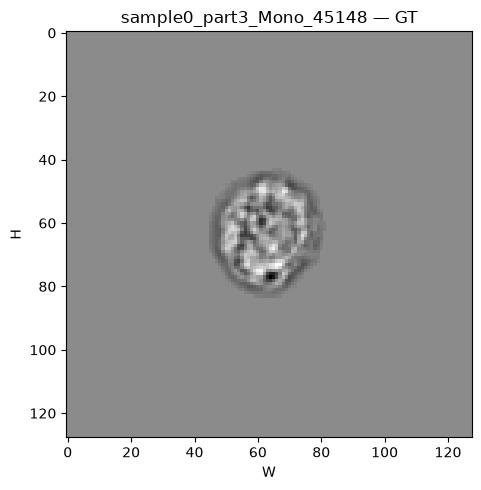

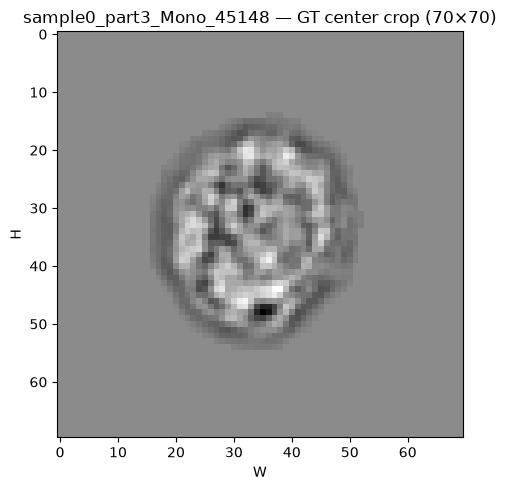

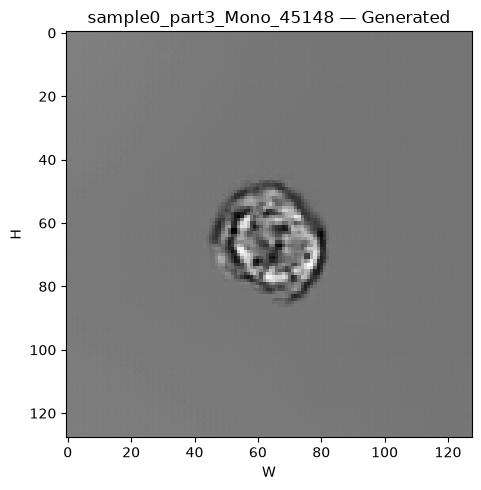

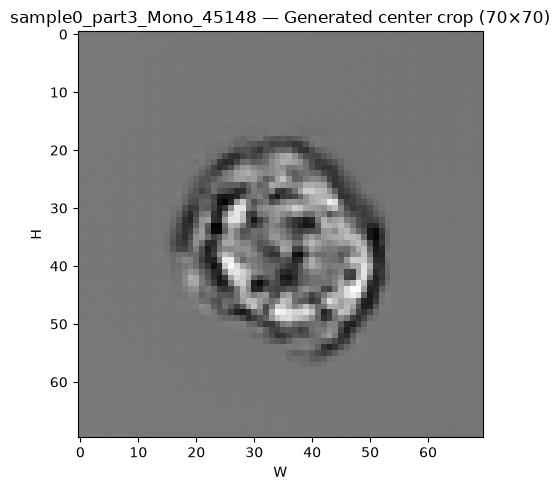

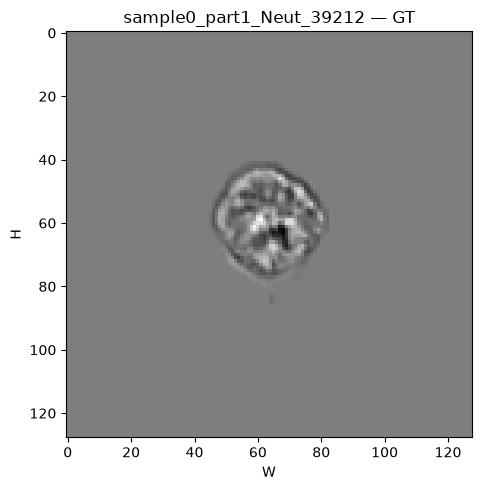

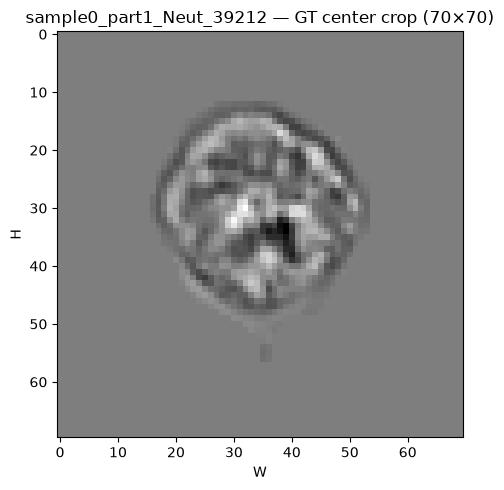

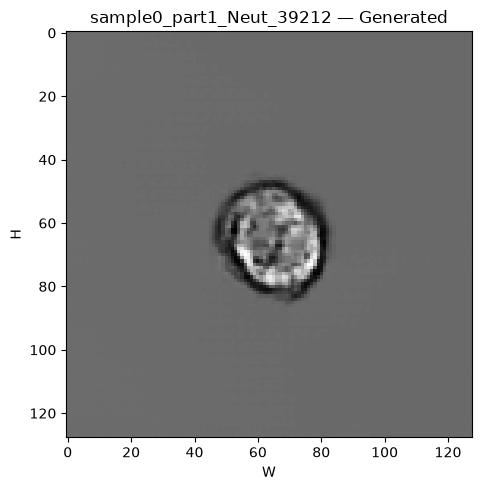

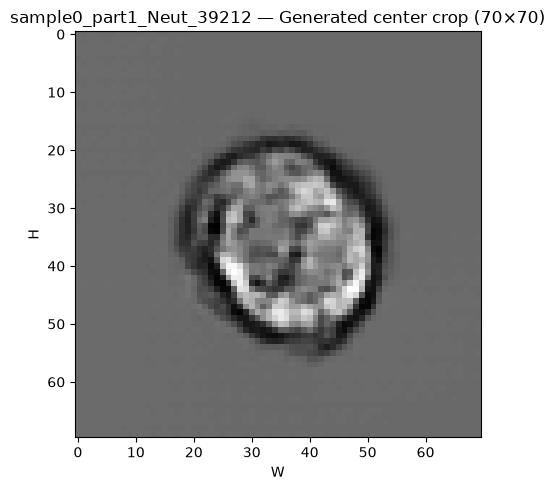

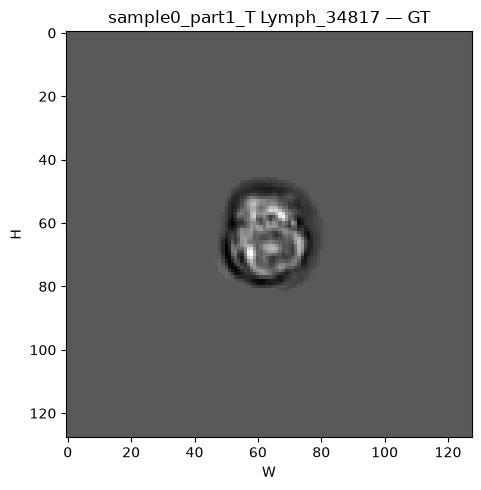

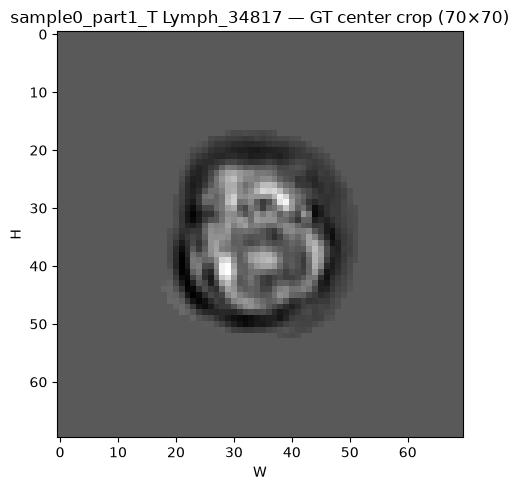

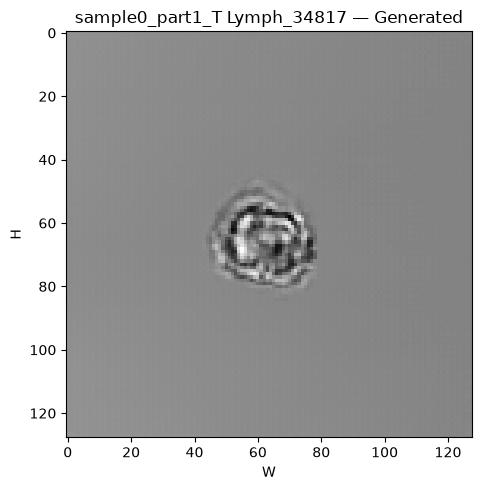

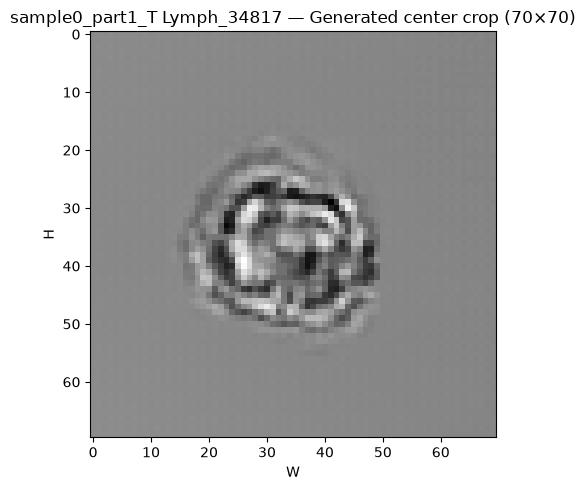

In [10]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
# PLOT DCGAN 70x70 CENTER CROP

import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("jpg")

from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np


# -------------------------------------------------------------------
# Paths
# -------------------------------------------------------------------

ROOT = Path("~/projects/fcmstylegan/experiments/archive/dcgan_baseline_20260817_231036").expanduser()


PREPROCESSED_ROOT = Path(
    "~/projects/fcmstylegan/data/task1_processed"
).expanduser()

GENERATED_DIR = ROOT / "test_eval_imgs"


# -------------------------------------------------------------------
# Cell IDs
# -------------------------------------------------------------------

cell_ids = [
    "sample0_part1_B Lymph_14408",
    "sample0_part3_Eo_5626",
    "sample0_part3_Mono_45148",
    "sample0_part1_Neut_39212",
    "sample0_part1_T Lymph_34817",
]

def center_crop(img, size=70):
    img = np.array(img)
    h, w = img.shape[:2]
    y0 = (h - size) // 2
    x0 = (w - size) // 2
    return img[y0:y0+size, x0:x0+size]


for cell_id in cell_ids:

    gt_path = PREPROCESSED_ROOT / f"{cell_id}_brightfield_crop_masked_normalized_avebg_pad128.png"
    gen_path = GENERATED_DIR / f"{cell_id.replace(' ', '_')}.png"

    gt = Image.open(gt_path)
    gen = Image.open(gen_path)

    gt_crop = center_crop(gt, 70)
    gen_crop = center_crop(gen, 70)

    # GT full
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(gt, cmap="gray")
    ax.set_title(f"{cell_id} — GT")
    ax.set_xlabel("W")
    ax.set_ylabel("H")
    plt.tight_layout()
    plt.show()

    # GT 70x70 center crop
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(gt_crop, cmap="gray")
    ax.set_title(f"{cell_id} — GT center crop (70×70)")
    ax.set_xlabel("W")
    ax.set_ylabel("H")
    ax.set_xticks(np.arange(0, 70, 10))
    ax.set_yticks(np.arange(0, 70, 10))
    ax.set_xlim(-0.5, 69.5)
    ax.set_ylim(69.5, -0.5)
    plt.tight_layout()
    plt.show()

    # Generated full
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(gen, cmap="gray")
    ax.set_title(f"{cell_id} — Generated")
    ax.set_xlabel("W")
    ax.set_ylabel("H")
    plt.tight_layout()
    plt.show()

    # Generated 70x70 center crop
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(gen_crop, cmap="gray")
    ax.set_title(f"{cell_id} — Generated center crop (70×70)")
    ax.set_xlabel("W")
    ax.set_ylabel("H")
    ax.set_xticks(np.arange(0, 70, 10))
    ax.set_yticks(np.arange(0, 70, 10))
    ax.set_xlim(-0.5, 69.5)
    ax.set_ylim(69.5, -0.5)
    plt.tight_layout()
    plt.show()


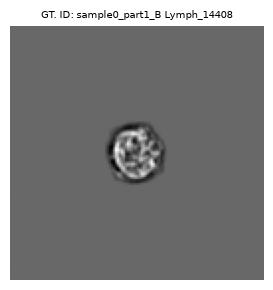

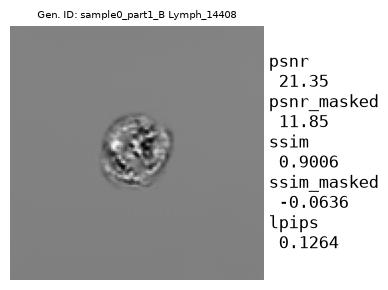

-------


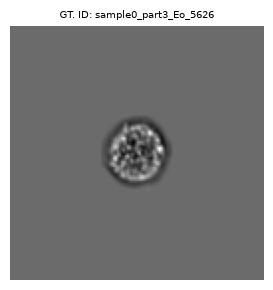

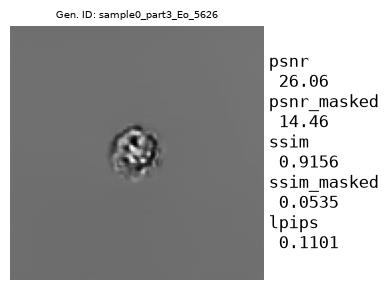

-------


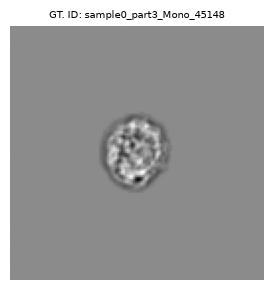

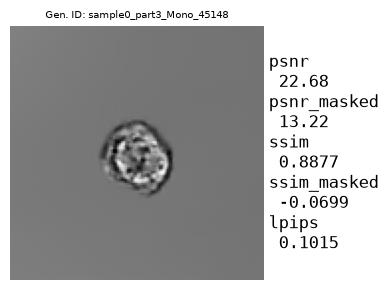

-------


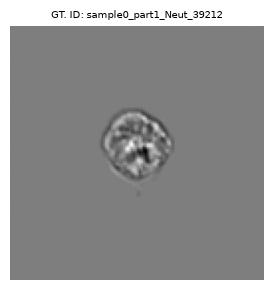

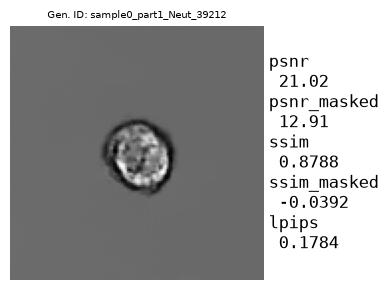

-------


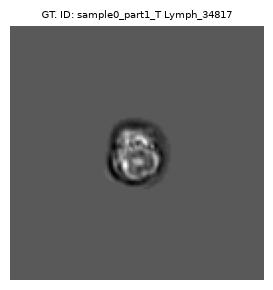

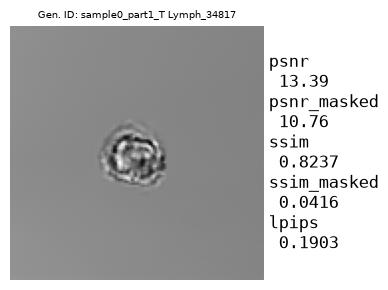

-------


In [27]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("jpg")
from PIL import Image

# Placeholder dependencies that need to be defined in your script:
# PREPROCESSED_ROOT = Path("...")
# GENERATED_DIR = Path("...")
# IMAGE_SUFFIX = ".png"
# available_metrics = [...]
# metric_decimals = {}
# df = pd.DataFrame(...)

# def safe_id(cell_id): ...
# def crop_to_mask(image, mask_path, resampling): ...

def show_image(ax, path, title, mask_path=None, cropped=False, mask=False, masked=False):
    ax.axis("off")
    if path.exists():
        # Preserve 16-bit/float image data; converting to L can wash out GT images.
        image = Image.open(path)
        if cropped:
            image = crop_to_mask(
                image, mask_path,
                resampling=Image.Resampling.NEAREST if mask else Image.Resampling.BILINEAR,
            )
        image_array = np.asarray(image)
        if masked:
            mask_image = Image.open(mask_path).convert("L").resize(image.size, Image.Resampling.NEAREST)
            mask_array = np.asarray(mask_image) > 0
            image_array = np.where(mask_array, image_array, image_array.min())
        ax.imshow(image_array, cmap="gray")
        ax.set_title(title, fontsize=7)
    else:
        ax.text(0.5, 0.5, f"Missing:\n{path}", ha="center", va="center", fontsize=8)

def _get_metrics_text(sample, metrics):
    """Format specified metrics into a single string with one line per metric."""
    lines = []
    for metric in metrics:
        val = sample[metric]
        decimals = metric_decimals.get(metric, 4)
        formatted_val = f"{val:.{decimals}f}" if pd.notna(val) else "N/A"
        lines.append(f"{metric}\n {formatted_val}")
    return "\n".join(lines)

def plot_gt(cell_id, figsize=(4, 4), show=True):
    """Plot Ground Truth image only."""
    matches = df[df["image_id"].astype(str) == str(cell_id)]
    if matches.empty:
        raise KeyError(f"Cell ID not found: {cell_id}")

    gt_path = PREPROCESSED_ROOT / f"{str(cell_id)}{IMAGE_SUFFIX}"

    fig, ax = plt.subplots(figsize=figsize)
    show_image(ax, gt_path, f"GT. ID: {cell_id}")

    plt.tight_layout()
    if show:
        plt.show()
    return fig, ax

def plot_gen(cell_id, metrics=None, figsize=(4, 4), fontsize=10, show=True):
    """Plot Generated image with metrics on the right."""
    matches = df[df["image_id"].astype(str) == str(cell_id)]
    if matches.empty:
        raise KeyError(f"Cell ID not found: {cell_id}")
    sample = matches.iloc[0]

    if metrics is None:
        metrics = available_metrics
    else:
        invalid = [m for m in metrics if m not in available_metrics]
        if invalid:
            raise ValueError(f"Unknown metric(s): {invalid}; choose from {available_metrics}")

    generated_path = GENERATED_DIR / f"{safe_id(cell_id)}.png"

    fig, ax = plt.subplots(figsize=figsize)
    show_image(ax, generated_path, f"Gen. ID: {cell_id}")
    
    metrics_str = _get_metrics_text(sample, metrics)
    fig.text(
        1.02, 0.5, metrics_str, 
        transform=ax.transAxes, 
        fontsize=fontsize, 
        verticalalignment='center', 
        family='monospace'
    )

    plt.tight_layout()
    if show:
        plt.show()
    return fig, ax
            
cell_ids = ['sample0_part1_B Lymph_14408',
 'sample0_part3_Eo_5626',
 'sample0_part3_Mono_45148',
 'sample0_part1_Neut_39212',
 'sample0_part1_T Lymph_34817']

metrics=["psnr", "psnr_masked", "ssim", "ssim_masked", "lpips", "lpips_crop"][:-1]
figsize=(3, 3)
fontsize=10


for cell_id in cell_ids:
    plot_gt(cell_id,figsize=figsize)
    plot_gen(cell_id,figsize=figsize,fontsize=12, metrics=metrics)
    print("-------")